# NB05: Direct FB-BacDive Case Studies

For the 12 FB organisms matching BacDive, present **descriptive case studies**.
n=12 is insufficient for formal hypothesis testing.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

MAIN_REPO = '/home/psdehal/pangenome_science/BERIL-research-observatory'
PROJ = os.path.join(MAIN_REPO, 'projects', 'bacdive_phenotype_metal_tolerance')
DATA_OUT = os.path.join(PROJ, 'data')
FIG_OUT = os.path.join(PROJ, 'figures')
BACDIVE = os.path.join(MAIN_REPO, 'data', 'bacdive_ingest')
METAL_ATLAS = os.path.join(MAIN_REPO, 'projects', 'metal_fitness_atlas', 'data')

In [2]:
# Load and match by NCBI taxonomy ID
org_map = pd.read_csv(os.path.join(MAIN_REPO, 'projects', 'conservation_vs_fitness', 'data', 'organism_mapping.tsv'), sep='\t')
bd_strain = pd.read_csv(os.path.join(BACDIVE, 'strain.tsv'), sep='\t')
bd_phys = pd.read_csv(os.path.join(BACDIVE, 'physiology.tsv'), sep='\t')
bd_mu = pd.read_csv(os.path.join(BACDIVE, 'metabolite_utilization.tsv'), sep='\t')
bd_enz = pd.read_csv(os.path.join(BACDIVE, 'enzyme.tsv'), sep='\t')

org_map_clean = org_map.dropna(subset=['taxonomyId']).copy()
org_map_clean['tax_str'] = org_map_clean['taxonomyId'].astype(int).astype(str)
bd_strain['tax_str'] = bd_strain['ncbi_taxid'].apply(lambda x: str(int(x)) if pd.notna(x) else '')

overlap = set(org_map_clean['tax_str']) & set(bd_strain[bd_strain['tax_str'] != '']['tax_str'])
fb_matched = org_map_clean[org_map_clean['tax_str'].isin(overlap)].drop_duplicates(subset='orgId')
print(f'Matched FB organisms: {len(fb_matched)}')

Matched FB organisms: 12


In [3]:
# Extract BacDive phenotypes for each matched organism
rows = []
for _, org in fb_matched.iterrows():
    org_strains = bd_strain[bd_strain['tax_str'] == org['tax_str']]
    org_ids = set(org_strains['bacdive_id'])
    op = bd_phys[bd_phys['bacdive_id'].isin(org_ids)]
    oe = bd_enz[bd_enz['bacdive_id'].isin(org_ids)]
    om = bd_mu[bd_mu['bacdive_id'].isin(org_ids)]
    def mode_or_na(s):
        m = s.dropna().mode()
        return m.iloc[0] if len(m) > 0 else 'N/A'
    def enz_s(name):
        e = oe[oe['enzyme_name'].str.contains(name, case=False, na=False) & oe['activity'].isin(['+', '-'])]
        if len(e) == 0: return 'N/A'
        p, n = (e['activity']=='+').sum(), (e['activity']=='-').sum()
        return f'+({p}/{p+n})' if p > n else f'-({n}/{p+n})'
    def met_s(compound):
        m = om[(om['compound_name']==compound) & om['utilization'].isin(['+','-','produced'])]
        if len(m) == 0: return 'N/A'
        p = m['utilization'].isin(['+','produced']).sum(); n = (m['utilization']=='-').sum()
        if p+n == 0: return 'N/A'
        return f'+({p}/{p+n})' if p > n else f'-({n}/{p+n})'
    rows.append({'orgId': org['orgId'], 'species': f"{org['genus']} {org['species']}",
        'n_strains': len(org_strains), 'gram': mode_or_na(op['gram_stain']),
        'oxygen': mode_or_na(op['oxygen_tolerance']),
        'catalase': enz_s('catalase'), 'oxidase': enz_s('oxidase'),
        'urease': enz_s('urease'), 'nitrate': met_s('nitrate'), 'h2s': met_s('hydrogen sulfide')})

pheno_df = pd.DataFrame(rows)
print(f'\n=== BacDive Phenotypes for {len(pheno_df)} FB Organisms ===')
print(pheno_df.to_string(index=False))


=== BacDive Phenotypes for 12 FB Organisms ===
             orgId                   species  n_strains     gram          oxygen catalase  oxidase   urease  nitrate    h2s
           Cup4G11    Cupriavidus basilensis         17 negative          aerobe   +(1/1) +(14/14) -(12/14) -(10/15)    N/A
  Methanococcus_JJ Methanococcus maripaludis          6      N/A        anaerobe      N/A      N/A      N/A      N/A    N/A
 RalstoniaBSBF1503    Ralstonia solanacearum         32      N/A             N/A      N/A   +(4/5)   -(3/5)   +(5/5)    N/A
    RalstoniaPSI07    Ralstonia solanacearum         32      N/A             N/A      N/A   +(4/5)   -(3/5)   +(5/5)    N/A
    RalstoniaUW163    Ralstonia solanacearum         32      N/A             N/A      N/A   +(4/5)   -(3/5)   +(5/5)    N/A
            WCS417        Pseudomonas simiae          2 negative          aerobe   +(1/1)   +(2/2)   -(2/2)   +(2/2)    N/A
            azobra   Azospirillum brasilense          1      N/A             N/A    

In [4]:
# Load metal experiments and merge
metal_exps = pd.read_csv(os.path.join(METAL_ATLAS, 'metal_experiments.csv'))
matched_metal = metal_exps[metal_exps['orgId'].isin(set(fb_matched['orgId']))]
metal_summary = matched_metal.groupby('orgId').agg(
    n_experiments=('expName', 'count'),
    metals=('metal_element', lambda x: ', '.join(sorted(x.unique()))),
    n_metals=('metal_element', 'nunique'),
).reset_index()
combined = pheno_df.merge(metal_summary, on='orgId', how='left')
combined.to_csv(os.path.join(DATA_OUT, 'fb_bacdive_combined.csv'), index=False)

print('=== Combined: Phenotype + Metal Experiments ===')
print(combined[['orgId','species','n_strains','gram','oxygen','catalase','urease','n_metals']].to_string(index=False))

print('\n=== Hypothesis Assessment ===')
print('H1a: All typed organisms are Gram-negative — cannot test within this set.')
print()
print('H1e (Urease → Ni):')
for _, r in combined.iterrows():
    if r['urease'] != 'N/A' and pd.notna(r.get('metals')):
        print(f'  {r["orgId"]:20s} urease={r["urease"]:12s} metals: {r["metals"]}')
print()
print('H1b (Oxygen → metal tolerance):')
for _, r in combined.iterrows():
    if r['oxygen'] != 'N/A' and pd.notna(r.get('metals')):
        print(f'  {r["orgId"]:20s} O2={r["oxygen"]:20s} n_metals={r.get("n_metals",0)}')

=== Combined: Phenotype + Metal Experiments ===
             orgId                   species  n_strains     gram          oxygen catalase   urease  n_metals
           Cup4G11    Cupriavidus basilensis         17 negative          aerobe   +(1/1) -(12/14)       5.0
  Methanococcus_JJ Methanococcus maripaludis          6      N/A        anaerobe      N/A      N/A       1.0
 RalstoniaBSBF1503    Ralstonia solanacearum         32      N/A             N/A      N/A   -(3/5)       NaN
    RalstoniaPSI07    Ralstonia solanacearum         32      N/A             N/A      N/A   -(3/5)       NaN
    RalstoniaUW163    Ralstonia solanacearum         32      N/A             N/A      N/A   -(3/5)       NaN
            WCS417        Pseudomonas simiae          2 negative          aerobe   +(1/1)   -(2/2)       4.0
            azobra   Azospirillum brasilense          1      N/A             N/A      N/A      N/A       NaN
pseudo13_GW456_L13   Pseudomonas fluorescens        103 negative obligate aerobe

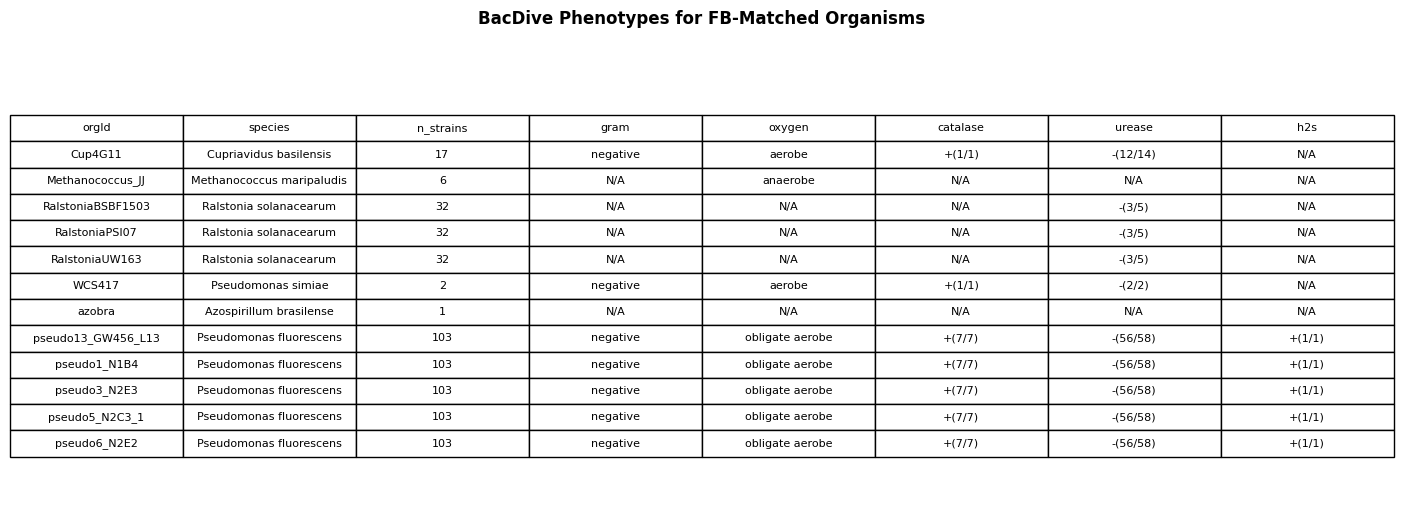

Saved: figures/fb_bacdive_phenotype_table.png


In [5]:
# Summary table figure
fig, ax = plt.subplots(figsize=(14, max(4, len(pheno_df)*0.45)))
ax.axis('off')
cols = ['orgId','species','n_strains','gram','oxygen','catalase','urease','h2s']
table = ax.table(cellText=pheno_df[cols].values.tolist(), colLabels=cols, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.4)
ax.set_title('BacDive Phenotypes for FB-Matched Organisms', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, 'fb_bacdive_phenotype_table.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/fb_bacdive_phenotype_table.png')